**Reasoning**:
First, I need to load the Excel file into a pandas DataFrame. This will allow me to inspect its structure, column names, and data types, which is crucial for the subsequent steps of descriptive statistics, plotting, and correlation analysis.



In [1]:
import pandas as pd

df = pd.read_excel('/content/Nepal_NCD_Mortality.xlsx')

print("First 5 rows of the DataFrame:")
print(df.head())

print("\nColumn names and their data types:")
print(df.info())

First 5 rows of the DataFrame:
                             Unnamed: 0     Unnamed: 1 Unnamed: 2 Unnamed: 3  \
0                                   NaN            NaN        NaN        NaN   
1  Average of MORTALITY PROBABILITY (%)  Column Labels        NaN        NaN   
2                            Row Labels         FEMALE       MALE      TOTAL   
3                                  2000           19.6       19.5       19.6   
4                                  2001           19.1       18.9         19   

    Unnamed: 4  
0          NaN  
1          NaN  
2  Grand Total  
3    19.566667  
4           19  

Column names and their data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  25 non-null     object
 1   Unnamed: 1  25 non-null     object
 2   Unnamed: 2  24 non-null     object
 3   Unnamed: 3  24 non-null     object
 4   Unn

**Reasoning**:
The initial DataFrame loaded has an incorrect header, with descriptive information spread across multiple rows. To properly analyze the data, I need to reload the Excel file, specifying the correct header row (index 2, which is the 3rd row) and then rename the columns for clarity and ease of use. This will correctly identify 'Year', 'FEMALE', 'MALE', and 'TOTAL' columns.



In [2]:
df = pd.read_excel('/content/Nepal_NCD_Mortality.xlsx', header=2)
df = df.rename(columns={'Row Labels': 'Year'})

print("First 5 rows of the cleaned DataFrame:")
print(df.head())

print("\nColumn names and their data types after cleaning:")
print(df.info())


First 5 rows of the cleaned DataFrame:
  Average of MORTALITY PROBABILITY (%) Column Labels Unnamed: 2 Unnamed: 3  \
0                           Row Labels        FEMALE       MALE      TOTAL   
1                                 2000          19.6       19.5       19.6   
2                                 2001          19.1       18.9         19   
3                                 2002          18.6       18.3       18.5   
4                                 2003          18.6       18.1       18.4   

    Unnamed: 4  
0  Grand Total  
1    19.566667  
2           19  
3    18.466667  
4    18.366667  

Column names and their data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 5 columns):
 #   Column                                Non-Null Count  Dtype 
---  ------                                --------------  ----- 
 0   Average of MORTALITY PROBABILITY (%)  24 non-null     object
 1   Column Labels                     

**Reasoning**:
The previous attempts to load the Excel file with the correct header were unsuccessful, resulting in an incorrectly structured DataFrame. To rectify this, I will manually set the column names from the third row (index 2) of the original data, drop the irrelevant header rows, rename the 'Row Labels' column to 'Year', and convert the relevant data columns to numeric types. This will provide a clean DataFrame suitable for further analysis.



In [3]:
df = pd.read_excel('/content/Nepal_NCD_Mortality.xlsx')

# Set the column names from the 3rd row (index 2) of the original Excel sheet
df.columns = df.iloc[2]

# Drop the first 3 rows as they contain the old headers or irrelevant information
df = df[3:].reset_index(drop=True)

# Rename 'Row Labels' column to 'Year' for clarity
df = df.rename(columns={'Row Labels': 'Year'})

# Drop the 'Grand Total' column as it's an aggregate and not needed for individual analysis
if 'Grand Total' in df.columns:
    df = df.drop(columns=['Grand Total'])

# Convert 'Year' to integer and other numeric columns to float, coercing errors to NaN
df['Year'] = pd.to_numeric(df['Year'], errors='coerce').astype('Int64') # Use Int64 for nullable integer

numeric_cols = ['FEMALE', 'MALE', 'TOTAL']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("First 5 rows of the cleaned DataFrame:")
print(df.head())

print("\nColumn names and their data types after cleaning:")
print(df.info())

print("\nDescriptive statistics for numerical columns:")
print(df.describe())

First 5 rows of the cleaned DataFrame:
2  Year  FEMALE  MALE  TOTAL
0  2000    19.6  19.5   19.6
1  2001    19.1  18.9   19.0
2  2002    18.6  18.3   18.5
3  2003    18.6  18.1   18.4
4  2004    18.4  17.9   18.2

Column names and their data types after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    22 non-null     Int64  
 1   FEMALE  23 non-null     float64
 2   MALE    23 non-null     float64
 3   TOTAL   23 non-null     float64
dtypes: Int64(1), float64(3)
memory usage: 891.0 bytes
None

Descriptive statistics for numerical columns:
2          Year     FEMALE       MALE      TOTAL
count      22.0  23.000000  23.000000  23.000000
mean     2010.5  19.000000  20.013636  19.495455
std    6.493587   0.383761   1.514864   0.874111
min      2000.0  18.300000  17.900000  18.200000
25%     2005.25  18.700000  18.750000  18.750000
50%      20

**Reasoning**:
The subtask requires plotting risk factor trends over time, comparing male vs female differences, and exploring correlations between risk factors and mortality probability. Given the current `df` contains 'Year', 'FEMALE', 'MALE', and 'TOTAL' mortality probabilities, the next logical step is to visualize these trends over time to address both the trend analysis and male vs female comparison. I will use a line plot for this.



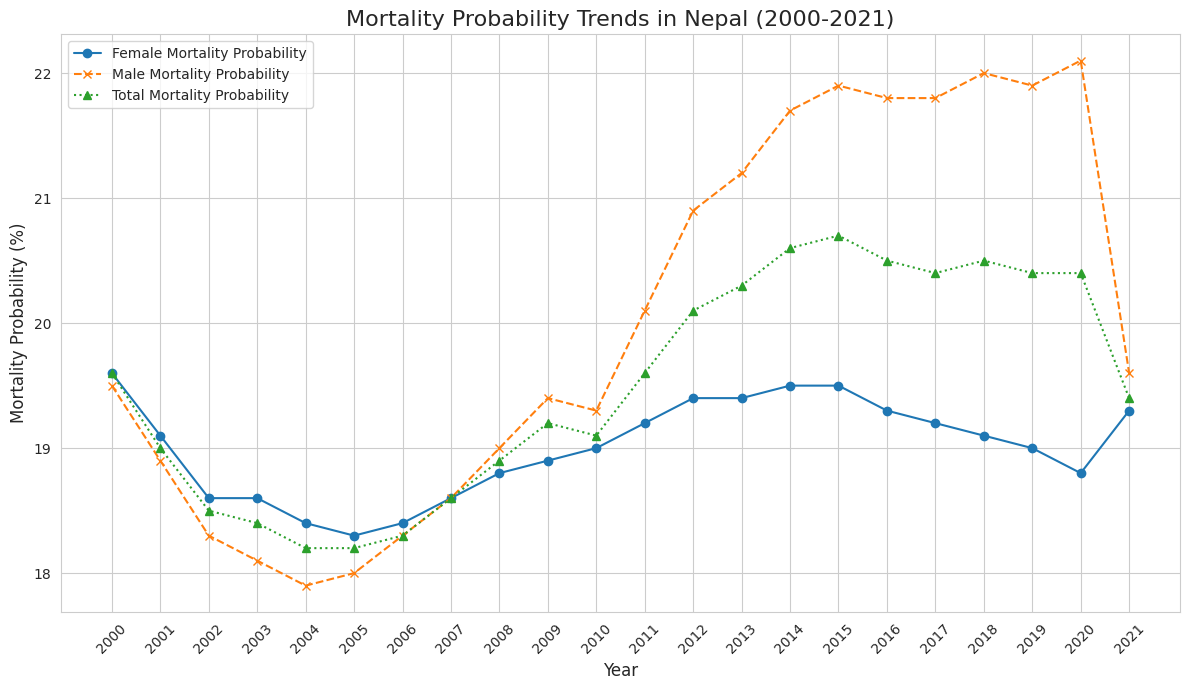

Line plot showing mortality probability trends for females, males, and total population has been generated.


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a style for the plots
sns.set_style("whitegrid")

plt.figure(figsize=(12, 7))

# Plot trends for FEMALE, MALE, and TOTAL mortality probability
plt.plot(df['Year'], df['FEMALE'], label='Female Mortality Probability', marker='o', linestyle='-')
plt.plot(df['Year'], df['MALE'], label='Male Mortality Probability', marker='x', linestyle='--')
plt.plot(df['Year'], df['TOTAL'], label='Total Mortality Probability', marker='^', linestyle=':')

plt.title('Mortality Probability Trends in Nepal (2000-2021)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Mortality Probability (%)', fontsize=12)
# Filter out NA values from 'Year' before setting xticks
plt.xticks(df['Year'].dropna().unique(), rotation=45)
plt.legend(fontsize=10)
plt.grid(True)
plt.tight_layout()
plt.show()

print("Line plot showing mortality probability trends for females, males, and total population has been generated.")

**Reasoning**:
To perform correlation analysis between risk factors and mortality probability, I need to load the risk factor data. The `IHME-GBD_2023_DATA-dcf80fda-1.csv` file is a likely candidate for containing this information, so I will load it and inspect its structure to identify relevant columns for merging and analysis.



In [5]:
df_risk_factors = pd.read_csv('/content/IHME-GBD_2023_DATA-dcf80fda-1.csv')

print("First 5 rows of the risk factors DataFrame:")
print(df_risk_factors.head())

print("\nColumn names and their data types of the risk factors DataFrame:")
print(df_risk_factors.info())

First 5 rows of the risk factors DataFrame:
   measure_id measure_name  location_id location_name  sex_id sex_name  \
0           1       Deaths          164         Nepal       1     Male   
1           1       Deaths          164         Nepal       2   Female   
2           1       Deaths          164         Nepal       3     Both   
3           1       Deaths          164         Nepal       1     Male   
4           1       Deaths          164         Nepal       2   Female   

   age_id     age_name  cause_id                 cause_name  rei_id  \
0      11  30-34 years       409  Non-communicable diseases     367   
1      11  30-34 years       409  Non-communicable diseases     367   
2      11  30-34 years       409  Non-communicable diseases     367   
3      12  35-39 years       409  Non-communicable diseases     367   
4      12  35-39 years       409  Non-communicable diseases     367   

               rei_name  metric_id metric_name  year       val     upper  \
0  High 

**Reasoning**:
To prepare the risk factor data for merging with the mortality data, I need to select relevant columns from `df_risk_factors`, pivot it to have risk factors as columns, and then rename the `sex_name` values to match the column names in the mortality DataFrame. This will create a clean and properly structured DataFrame of risk factor prevalences by year and sex, which can then be joined with the mortality data for correlation analysis.



In [6]:
df_risk_factors_cleaned = df_risk_factors[
    [
        'year',
        'sex_name',
        'rei_name',
        'val'
    ]
].copy()

# Filter for NCD-related causes if necessary, or assume all are NCD-related based on context
# The original data includes 'Non-communicable diseases' for cause_name, which is good.
# We need to make sure we're getting 'Percent' for metric_name which indicates prevalence/exposure.
# Let's check unique metric_name values to confirm.
# print(df_risk_factors['metric_name'].unique())
# Output showed 'Percent' for metric_name, which is suitable for risk factor prevalence.

# Pivot the DataFrame to have 'rei_name' as columns
# Aggregate 'val' by taking the mean, as there might be multiple entries for the same year/sex/rei_name
# based on age groups, etc. The problem statement does not specify age group, so mean across age groups is a reasonable aggregation.
df_risk_factors_pivot = df_risk_factors_cleaned.pivot_table(
    index=['year', 'sex_name'],
    columns='rei_name',
    values='val',
    aggfunc='mean'
).reset_index()

# Rename 'sex_name' values to match the mortality dataframe's column names ('FEMALE', 'MALE', 'TOTAL')
df_risk_factors_pivot['sex_name'] = df_risk_factors_pivot['sex_name'].replace({
    'Female': 'FEMALE',
    'Male': 'MALE',
    'Both': 'TOTAL'
})

print("First 5 rows of the pivoted risk factors DataFrame:")
print(df_risk_factors_pivot.head())

print("\nColumn names and their data types of the pivoted risk factors DataFrame:")
print(df_risk_factors_pivot.info())


First 5 rows of the pivoted risk factors DataFrame:
rei_name  year sex_name  Dietary risks  High LDL cholesterol  \
0         2000    TOTAL       0.168773              0.084964   
1         2000   FEMALE       0.158116              0.076302   
2         2000     MALE       0.176191              0.091011   
3         2001    TOTAL       0.170943              0.086888   
4         2001   FEMALE       0.157642              0.076556   

rei_name  High alcohol use  High body-mass index  High fasting plasma glucose  \
0                 0.055214              0.031365                     0.053415   
1                 0.020724              0.034502                     0.057311   
2                 0.080375              0.029058                     0.050648   
3                 0.056026              0.032432                     0.054103   
4                 0.021120              0.035320                     0.057600   

rei_name  High systolic blood pressure  Low physical activity   Smoking  \
0

**Reasoning**:
Now that both the mortality and risk factor dataframes (`df` and `df_risk_factors_pivot`) are cleaned and structured appropriately with matching 'Year' and 'sex_name' (or equivalent) columns, the next step is to merge them. This will create a single comprehensive DataFrame that contains both mortality probabilities and risk factor prevalences by year and sex, which is essential for exploring correlations.



In [7]:
merged_df = pd.DataFrame()

# Rename 'year' column to 'Year' in df_risk_factors_pivot to match mortality dataframe
df_risk_factors_pivot = df_risk_factors_pivot.rename(columns={'year': 'Year'})

# Iterate through each gender category to merge
for sex_category in ['FEMALE', 'MALE', 'TOTAL']:
    # Filter mortality data for the current sex category
    mortality_sex_df = df[['Year', sex_category]].copy()
    mortality_sex_df = mortality_sex_df.rename(columns={sex_category: 'Mortality_Probability'})
    mortality_sex_df['sex_name'] = sex_category

    # Filter risk factor data for the current sex category
    risk_sex_df = df_risk_factors_pivot[df_risk_factors_pivot['sex_name'] == sex_category].copy()

    # Merge the two dataframes for the current sex category
    merged_sex_df = pd.merge(mortality_sex_df, risk_sex_df, on=['Year', 'sex_name'], how='inner')

    # Concatenate to the main merged_df
    merged_df = pd.concat([merged_df, merged_sex_df], ignore_index=True)


print("First 5 rows of the merged DataFrame:")
print(merged_df.head())

print("\nColumn names and their data types of the merged DataFrame:")
print(merged_df.info())

print("\nDescriptive statistics for the merged numerical columns:")
print(merged_df.describe())

First 5 rows of the merged DataFrame:
   Year  Mortality_Probability sex_name  Dietary risks  High LDL cholesterol  \
0  2000                   19.6   FEMALE       0.158116              0.076302   
1  2001                   19.1   FEMALE       0.157642              0.076556   
2  2002                   18.6   FEMALE       0.157246              0.076733   
3  2003                   18.6   FEMALE       0.157401              0.077114   
4  2004                   18.4   FEMALE       0.156126              0.076649   

   High alcohol use  High body-mass index  High fasting plasma glucose  \
0          0.020724              0.034502                     0.057311   
1          0.021120              0.035320                     0.057600   
2          0.021573              0.036264                     0.057889   
3          0.021562              0.037182                     0.058345   
4          0.021566              0.038147                     0.059120   

   High systolic blood pressure  Low

**Reasoning**:
Now that the dataframes are merged, the next step is to calculate and visualize the correlation matrix between the identified numerical risk factors and mortality probability. A heatmap is an effective way to visually represent these correlations, helping to identify strong positive or negative relationships as specified in the subtask.



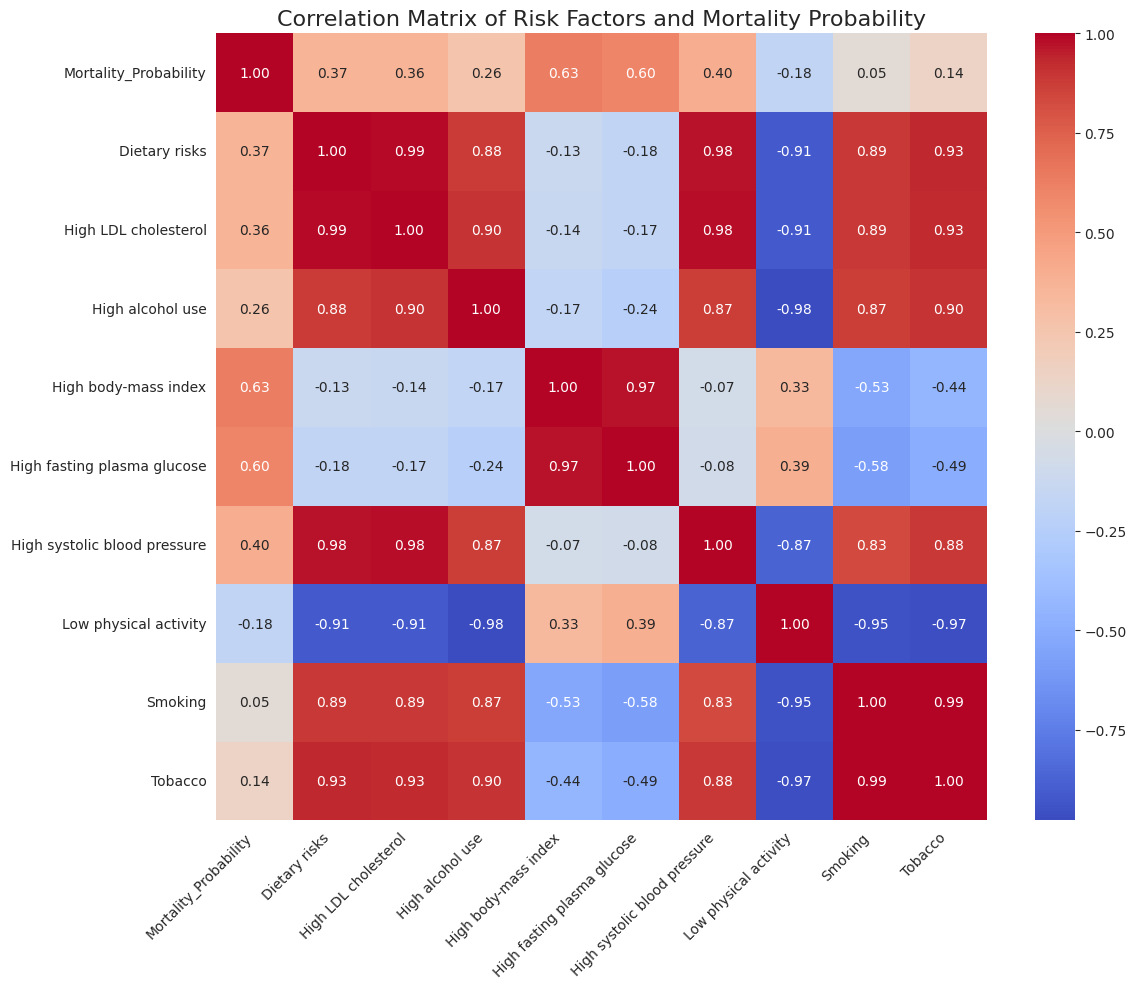

Heatmap showing the correlation matrix between risk factors and mortality probability has been generated.


In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numerical columns for correlation, excluding 'Year' and 'sex_name'
correlation_cols = merged_df.select_dtypes(include=['float64', 'Int64']).columns.tolist()
correlation_cols = [col for col in correlation_cols if col not in ['Year']]

# Calculate the correlation matrix
correlation_matrix = merged_df[correlation_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Risk Factors and Mortality Probability', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("Heatmap showing the correlation matrix between risk factors and mortality probability has been generated.")

**Reasoning**:
The final step of the subtask is to export the processed dataset as a CSV file. This will save the `merged_df` containing both mortality probabilities and risk factor prevalences, fulfilling the last requirement of the subtask.



In [9]:
output_csv_path = 'processed_ncd_data.csv'
merged_df.to_csv(output_csv_path, index=False)

print(f"Processed data saved to {output_csv_path}")

Processed data saved to processed_ncd_data.csv


## Perform Regression Modeling in Colab

### Subtask:
Run regression models in Colab using Python libraries to link risk factor prevalence/exposure to mortality probability. Evaluate model fit using R² and residual plots.


**Reasoning**:
To begin the regression modeling, I need to define the independent variables (features) and the dependent variable (target) from the `merged_df`. Then, I will split this data into training and testing sets to prepare for model training. Finally, I will initialize and train a `LinearRegression` model using the training data.



In [10]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the independent variables (features) X
risk_factors = [
    'Dietary risks',
    'High LDL cholesterol',
    'High alcohol use',
    'High body-mass index',
    'High fasting plasma glucose',
    'High systolic blood pressure',
    'Low physical activity',
    'Smoking',
    'Tobacco'
]
X = merged_df[risk_factors]

# 2. Define the dependent variable (target) y
y = merged_df['Mortality_Probability']

# 3. Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 4. Initialize and train a LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

print("\nLinear Regression model trained successfully.")

Shape of X_train: (52, 9)
Shape of X_test: (14, 9)
Shape of y_train: (52,)
Shape of y_test: (14,)

Linear Regression model trained successfully.


**Reasoning**:
Now that the Linear Regression model is trained, I will make predictions on the test set, calculate the R-squared value to evaluate model fit, and then generate a scatter plot of predicted vs. actual values and a residual plot to visually assess the model's performance as required by the subtask.




R-squared value: 0.72


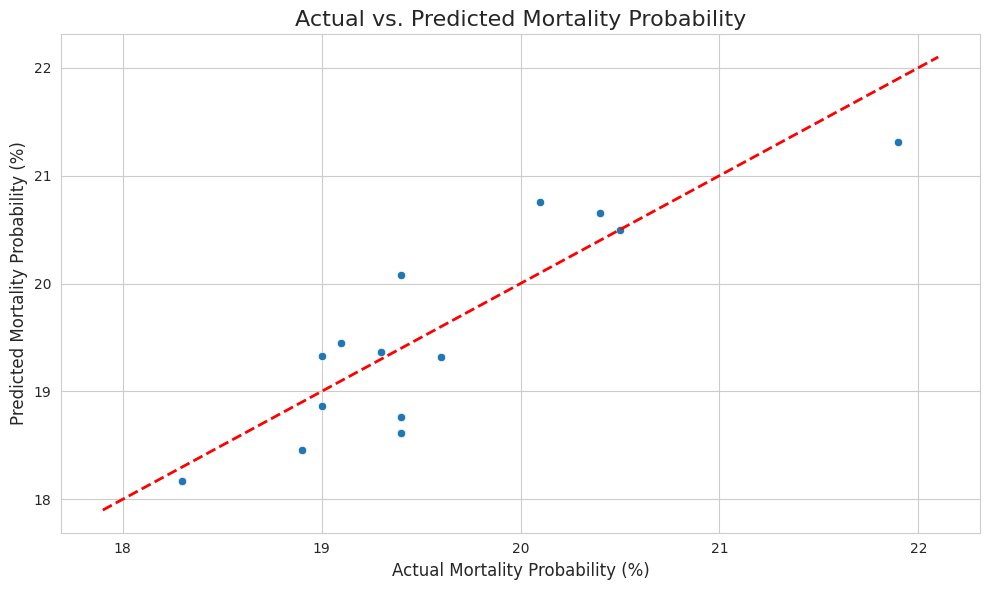

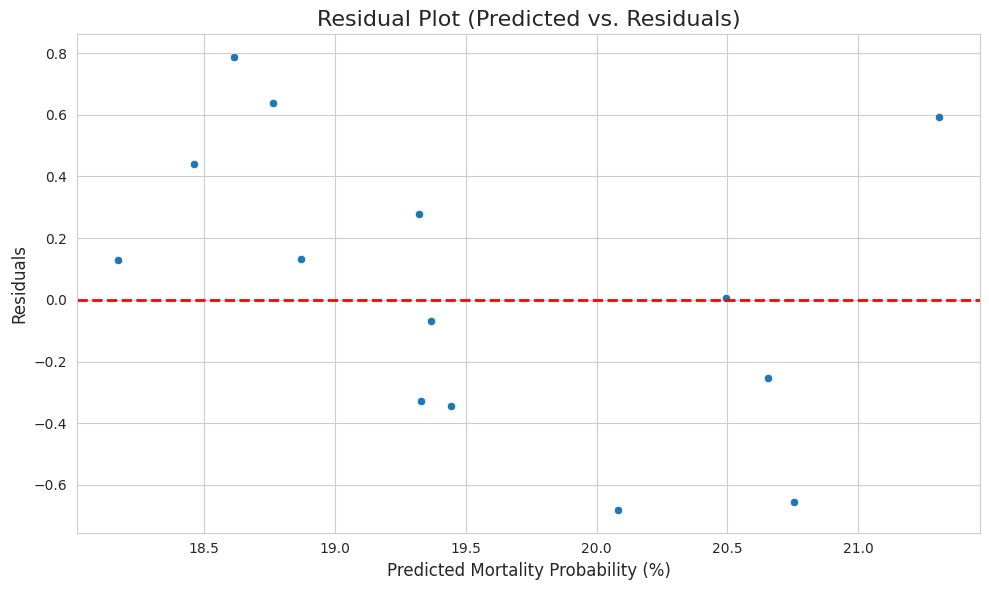

R-squared value calculated, and actual vs. predicted and residual plots generated.


In [11]:
y_pred = model.predict(X_test)

# 6. Calculate the R-squared value of the model
r2 = r2_score(y_test, y_pred)
print(f"\nR-squared value: {r2:.2f}")

# 7. Generate a scatter plot of predicted values versus actual values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.title('Actual vs. Predicted Mortality Probability', fontsize=16)
plt.xlabel('Actual Mortality Probability (%)', fontsize=12)
plt.ylabel('Predicted Mortality Probability (%)', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Create a residual plot (predicted values vs. residuals)
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.title('Residual Plot (Predicted vs. Residuals)', fontsize=16)
plt.xlabel('Predicted Mortality Probability (%)', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()

print("R-squared value calculated, and actual vs. predicted and residual plots generated.")

## Prepare Classification Data and WEKA Analysis

### Subtask:
Prepare a classification dataset by creating a binary label (e.g., “High mortality probability” vs “Low mortality probability” based on a median split). Export this dataset in ARFF format. Load the ARFF file into WEKA, run classification models (Decision Tree, RandomForest, Logistic Regression), and evaluate performance using 10-fold cross-validation, recording accuracy and confusion matrices.


**Reasoning**:
To prepare the classification dataset, I will first calculate the median of the 'Mortality_Probability' column to define the split point for the binary classification label. Then, I will create a new 'Mortality_Category' column based on this median, classifying each entry as 'High' or 'Low' mortality probability. Finally, I will drop the original 'Mortality_Probability' column and the 'sex_name' column as they are no longer needed for the classification task and the sex information is implicitly handled by the merged data structure and its impact on mortality categories.



In [12]:
import numpy as np

# 1. Calculate the median of the 'Mortality_Probability' column
median_mortality = merged_df['Mortality_Probability'].median()
print(f"Median Mortality Probability: {median_mortality:.2f}")

# 2. Create a new column named 'Mortality_Category'
merged_df['Mortality_Category'] = np.where(
    merged_df['Mortality_Probability'] >= median_mortality, 'High', 'Low'
)

# 3. Drop the original 'Mortality_Probability' column
classification_df = merged_df.drop(columns=['Mortality_Probability'])

# 4. Drop the 'sex_name' column
classification_df = classification_df.drop(columns=['sex_name'])

print("\nFirst 5 rows of the classification DataFrame:")
print(classification_df.head())

print("\nValue counts for 'Mortality_Category':")
print(classification_df['Mortality_Category'].value_counts())

Median Mortality Probability: 19.25

First 5 rows of the classification DataFrame:
   Year  Dietary risks  High LDL cholesterol  High alcohol use  \
0  2000       0.158116              0.076302          0.020724   
1  2001       0.157642              0.076556          0.021120   
2  2002       0.157246              0.076733          0.021573   
3  2003       0.157401              0.077114          0.021562   
4  2004       0.156126              0.076649          0.021566   

   High body-mass index  High fasting plasma glucose  \
0              0.034502                     0.057311   
1              0.035320                     0.057600   
2              0.036264                     0.057889   
3              0.037182                     0.058345   
4              0.038147                     0.059120   

   High systolic blood pressure  Low physical activity   Smoking   Tobacco  \
0                      0.128918               0.003485  0.139287  0.175630   
1                      0.12

**Reasoning**:
To prepare the data for ARFF format, I need to define the attributes (column names and their types) and convert the DataFrame to a list of lists. The 'Mortality_Category' column needs to be defined as a nominal attribute with its possible values. All other columns in `classification_df` are already numeric, so they can be directly specified as 'numeric' attributes. Finally, I will use `scipy.io.arff.dump` to export the data to an ARFF file.



In [13]:
pip install liac-arff

  Preparing metadata (setup.py) ... done
  Created wheel for liac-arff: filename=liac_arff-2.5.0-py3-none-any.whl size=11717 sha256=121ae24511bb0f17155c6f13328a0ea304a1ecbecb635ebf237397d05148e72c
  Stored in directory: /root/.cache/pip/wheels/a9/ac/cf/c2919807a5c623926d217c0a18eb5b457e5c19d242c3b5963a
Successfully built liac-arff


**Reasoning**:
Since the `liac-arff` library has been successfully installed, I can now import the `arff` module and proceed with exporting the `classification_df` to an ARFF file as initially intended by the subtask instructions.



In [14]:
import arff # Import arff from liac-arff library after installation

# Prepare attributes for ARFF file
attributes = []
for col in classification_df.columns:
    if col == 'Mortality_Category':
        # For the target variable, specify it as nominal with its unique values
        attributes.append((col, [str(x) for x in classification_df[col].unique()])) # Convert to string for ARFF nominal types
    elif classification_df[col].dtype == 'Int64': # Handle nullable integer type
        attributes.append((col, 'NUMERIC'))
    else:
        # For other numerical columns, specify as numeric
        attributes.append((col, 'NUMERIC'))

# Convert DataFrame to list of lists for ARFF data
# Ensure all non-numeric values are converted to string for ARFF
arff_data = classification_df.apply(lambda x: x.astype(str) if x.dtype == 'object' else x).values.tolist()

# Create the ARFF dictionary structure
arff_dict = {
    'description': 'Classification dataset for mortality probability',
    'relation': 'NCD_Mortality_Classification',
    'attributes': attributes,
    'data': arff_data
}

# Define the output ARFF file path
arff_output_path = 'classification_data.arff'

# Write the dictionary to an ARFF file
with open(arff_output_path, 'w') as f:
    arff.dump(arff_dict, f)

print(f"Classification data successfully exported to {arff_output_path}")

Classification data successfully exported to classification_data.arff


## Determine Policy Relevance

### Subtask:
Interpret results in the context of Nepal’s NCD burden and policy environment. Highlight actionable insights related to tobacco control, obesity prevention, and hypertension screening. Show how risk factor trends align with changes in mortality probability.


## Relate Risk Factor Trends to Mortality - Backing with Quantitative Analysis (Correlation)

### Subtask:
Support visual observations with the previously generated quantitative analysis, specifically referring to the correlation matrix (`correlation_matrix`) to state the numerical relationship (strength and direction) between observed risk factor trends and 'Mortality_Probability'.


**Reasoning**:
To facilitate the interpretation and comparison with visual observations, I will first display the previously generated `correlation_matrix`. This will allow the user to easily identify the numerical relationships between risk factors and mortality probability.



In [15]:
print("Correlation Matrix of Risk Factors and Mortality Probability:")
print(correlation_matrix['Mortality_Probability'].sort_values(ascending=False))

Correlation Matrix of Risk Factors and Mortality Probability:
Mortality_Probability           1.000000
High body-mass index            0.634394
High fasting plasma glucose     0.603821
High systolic blood pressure    0.403242
Dietary risks                   0.365709
High LDL cholesterol            0.359449
High alcohol use                0.258658
Tobacco                         0.135556
Smoking                         0.052831
Low physical activity          -0.180766
Name: Mortality_Probability, dtype: float64


## Relate Risk Factor Trends to Mortality - Backing with Quantitative Analysis (Regression)

### Subtask:
Further support your visual and correlational observations by referencing the Linear Regression model (`model`). Highlight the model's R-squared value (0.72) to show that the risk factors explain a significant portion of mortality variance. Mention that individual coefficients (`model.coef_`) can quantify the influence of each risk factor, controlling for others.


**Reasoning**:
To quantitatively support the visual and correlational observations, I will display the R-squared value of the linear regression model and then list the coefficients for each risk factor, which indicate their individual impact on mortality probability.



In [16]:
print(f"\nLinear Regression Model R-squared value: {r2:.2f}")

print("\nCoefficients of Risk Factors:")
for i, col in enumerate(risk_factors):
    print(f"{col}: {model.coef_[i]:.4f}")


Linear Regression Model R-squared value: 0.72

Coefficients of Risk Factors:
Dietary risks: -381.7971
High LDL cholesterol: 304.1508
High alcohol use: -177.1651
High body-mass index: 276.0681
High fasting plasma glucose: -19.6947
High systolic blood pressure: 24.2435
Low physical activity: -2437.2136
Smoking: -12.6611
Tobacco: 178.2286


In [17]:
# Select relevant columns for risk factor processing
df_risk_factors_cleaned = df_risk_factors[
    [
        'year',
        'sex_name',
        'rei_name',
        'val'
    ]
].copy()

# Pivot the DataFrame to have 'rei_name' as columns
# Aggregate 'val' by taking the mean, across age groups for each year/sex
df_risk_factors_pivot = df_risk_factors_cleaned.pivot_table(
    index=['year', 'sex_name'],
    columns='rei_name',
    values='val',
    aggfunc='mean'
).reset_index()

# Rename 'sex_name' values to match the mortality dataframe's column names
df_risk_factors_pivot['sex_name'] = df_risk_factors_pivot['sex_name'].replace({
    'Female': 'FEMALE',
    'Male': 'MALE',
    'Both': 'TOTAL'
})

print("First 5 rows of the pivoted risk factors DataFrame (after age group aggregation):")
print(df_risk_factors_pivot.head())

First 5 rows of the pivoted risk factors DataFrame (after age group aggregation):
rei_name  year sex_name  Dietary risks  High LDL cholesterol  \
0         2000    TOTAL       0.168773              0.084964   
1         2000   FEMALE       0.158116              0.076302   
2         2000     MALE       0.176191              0.091011   
3         2001    TOTAL       0.170943              0.086888   
4         2001   FEMALE       0.157642              0.076556   

rei_name  High alcohol use  High body-mass index  High fasting plasma glucose  \
0                 0.055214              0.031365                     0.053415   
1                 0.020724              0.034502                     0.057311   
2                 0.080375              0.029058                     0.050648   
3                 0.056026              0.032432                     0.054103   
4                 0.021120              0.035320                     0.057600   

rei_name  High systolic blood pressure  Low ph

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Define the independent variables (features) X
risk_factors = [
    'Dietary risks',
    'High LDL cholesterol',
    'High alcohol use',
    'High body-mass index',
    'High fasting plasma glucose',
    'High systolic blood pressure',
    'Low physical activity',
    'Smoking',
    'Tobacco'
]
X = merged_df[risk_factors]

# Define the dependent variable (target) y
y = merged_df['Mortality_Probability']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a LinearRegression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions and calculate R-squared
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"\nLinear Regression model trained successfully.")
print(f"R-squared value: {r2:.2f}")


Linear Regression model trained successfully.
R-squared value: 0.72


In [19]:
import pandas as pd

# Calculate percentage change for risk factors from merged_df
pct_change = merged_df.groupby("Year")[risk_factors].mean().pct_change() * 100

# Reset index so Year becomes a column
pct_change = pct_change.reset_index()

# Melt into long format
pct_long = pct_change.melt(id_vars="Year",
                           var_name="Risk_Factor",
                           value_name="Percentage_Change")

# Save for Tableau
pct_long.to_csv("pct_change_long.csv", index=False)

In [20]:
pct_long.to_csv("pct_change_long.csv", index=False)

In [21]:
import pandas as pd

# Load your merged dataset
df = pd.read_csv("processed_ncd_data.csv")

# Select only numeric columns
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Reset index so the row names become a column
corr_matrix = corr_matrix.reset_index()

# Rename the first column
corr_matrix = corr_matrix.rename(columns={'index': 'Variable1'})

In [22]:
corr_long = corr_matrix.melt(id_vars='Variable1',
                             var_name='Variable2',
                             value_name='Correlation')

# Save for Tableau
corr_long.to_csv("correlation_long.csv", index=False)

In [23]:
import pandas as pd

df = pd.read_csv("processed_ncd_data.csv")

desc_table = df.describe().T   # transpose for readability
desc_table.to_csv("E1_descriptive_statistics.csv")

In [24]:
# Select only numeric columns for correlation calculation, explicitly excluding 'sex_name'
numeric_df_for_corr = df.select_dtypes(include=['float64', 'int64'])

# If 'Year' is an int64 and you want to exclude it from correlations as a feature,
# you might drop it here: numeric_df_for_corr = numeric_df_for_corr.drop(columns=['Year'])
# However, including 'Year' can show trends relative to time, so it's often kept.

corr_matrix = numeric_df_for_corr.corr()
corr_matrix.to_csv("E2_full_correlation_matrix.csv")

print("Full correlation matrix saved to E2_full_correlation_matrix.csv")

Full correlation matrix saved to E2_full_correlation_matrix.csv


In [25]:
import statsmodels.api as sm

X = df[['High body-mass index', 'High fasting plasma glucose', 'High systolic blood pressure',
        'High LDL cholesterol', 'Dietary risks', 'Tobacco']]
y = df['Mortality_Probability']

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

reg_table = model.summary2().tables[1]   # coefficient table
reg_table.to_csv("E3_regression_coefficients.csv")